<div class="alert alert-block alert-success">
<b>ALL CLASSES TOGETHER</b>
</div>

<div class="alert alert-block alert-danger">

CREATING LAYERS: FORWARD AND BACKWARD PASS</div>

In [1]:
# Dense layer
class Layer_Dense:
    # Layer initialization
    def __init__(self, n_inputs, n_neurons):
        # Initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    # Forward pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs
        # Calculate output values from input ones, weights and biases
        self.output = np.dot(inputs, self.weights) + self.biases

    # Backward pass
    def backward(self, dvalues):
        # Gradients on parameters
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        # Gradient on values
        self.dinputs = np.dot(dvalues, self.weights.T)


<div class="alert alert-block alert-danger">

RELU ACTIVATION: FORWARD AND BACKWARD PASS</div>

In [2]:
# ReLU activation
class Activation_ReLU:
    # Forward pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs
        # Calculate output values from inputs
        self.output = np.maximum(0, inputs)

    # Backward pass
    def backward(self, dvalues):
        # Since we need to modify the original variable,
        # let’s make a copy of values first
        self.dinputs = dvalues.copy()
        # Zero gradient where input values were negative
        self.dinputs[self.inputs <= 0] = 0


<div class="alert alert-block alert-danger">

SOFTMAX ACTIVATION: FORWARD PASS</div>

In [3]:
# Softmax activation
class Activation_Softmax:
 # Forward pass
 def forward(self, inputs):
 # Get unnormalized probabilities
  exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
 # Normalize them for each sample
  probabilities = exp_values / np.sum(exp_values, axis=1,keepdims=True)
  self.output = probabilities

<div class="alert alert-block alert-danger">
LOSS CLASS </div>

In [4]:
# Common loss class
class Loss:
 # Calculates the data and regularization losses
 # given model output and ground truth values
 def calculate(self, output, y):
  # Calculate sample losses
  sample_losses = self.forward(output, y)
  # Calculate mean loss
  data_loss = np.mean(sample_losses)
  # Return loss
  return data_loss

<div class="alert alert-block alert-danger">

CATEGORICAL CROSS ENTROPY LOSS: FORWARD AND BACKWARD PASS</div>

In [5]:
class Loss_CategoricalCrossentropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):
        # Number of samples in a batch
        samples = len(y_pred)

        # Clip data to prevent division by 0
        # Clip both sides to not drag mean towards any value
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        # Probabilities for target values -
        # only if categorical labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
        # Mask values - only for one-hot encoded labels
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis=1
            )

        # Losses
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods

    # Backward pass
    def backward(self, dvalues, y_true):
        # Number of samples
        samples = len(dvalues)
        # Number of labels in every sample
        # We'll use the first sample to count them
        labels = len(dvalues[0])

        # If labels are sparse, turn them into one-hot vector
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]

        # Calculate gradient
        self.dinputs = -y_true / dvalues
        # Normalize gradient
        self.dinputs = self.dinputs / samples

<div class="alert alert-block alert-danger">

COMBINED SOFTMAX ACTIVATION AND CATEGORICAL CROSS ENTROPY FOR LAST LAYER: FORWARD AND BACKWARD PASS</div>

In [6]:
# Softmax classifier - combined Softmax activation
# and cross-entropy loss for faster backward step
class Activation_Softmax_Loss_CategoricalCrossentropy:
    # Creates activation and loss function objects
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()

    # Forward pass
    def forward(self, inputs, y_true):
        # Output layer's activation function
        self.activation.forward(inputs)
        # Set the output
        self.output = self.activation.output
        # Calculate and return loss value
        return self.loss.calculate(self.output, y_true)

    # Backward pass
    def backward(self, dvalues, y_true):
        # Number of samples
        samples = len(dvalues)
        # If labels are one-hot encoded,
        # turn them into discrete values
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        # Copy so we can safely modify
        self.dinputs = dvalues.copy()
        # Calculate gradient
        self.dinputs[range(samples), y_true] -= 1
        # Normalize gradient
        self.dinputs = self.dinputs / samples

<div class="alert alert-block alert-danger">

DATASET</div>

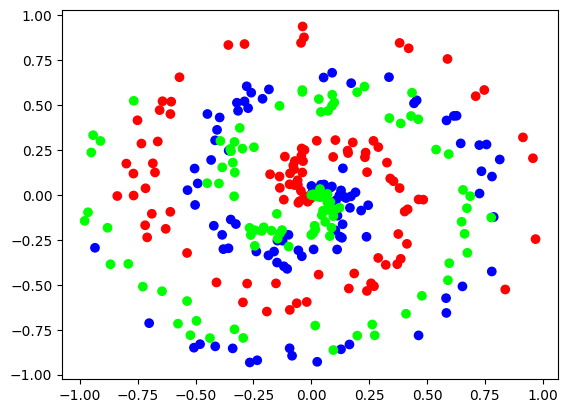

In [7]:
!pip install nnfs
import nnfs
from nnfs.datasets import spiral_data
import numpy as np
nnfs.init()
import matplotlib.pyplot as plt
X, y = spiral_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

<div class="alert alert-block alert-success">
<b>FULL CODE UPTO THIS POINT: FORWARD AND BACKWARD PASS</b>
</div>

In [8]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)
# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()
# Create second Dense layer with 3 input features (as we take output
# of previous layer here) and 3 output values (output values)
dense2 = Layer_Dense(3, 3)
# Create Softmax classifier’s combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()
# Perform a forward pass of our training data through this layer
dense1.forward(X)
# Perform a forward pass through activation function
# takes the output of first dense layer here
activation1.forward(dense1.output)
# Perform a forward pass through second Dense layer
# takes outputs of activation function of first layer as inputs
dense2.forward(activation1.output)
# Perform a forward pass through the activation/loss function
# takes the output of second dense layer here and returns loss
loss = loss_activation.forward(dense2.output, y)

# Let’s see output of the first few samples:
print(loss_activation.output[:5])
# Print loss value
print('loss:', loss)
# Calculate accuracy from output of activation2 and targets
# calculate values along first axis
predictions = np.argmax(loss_activation.output, axis=1)
if len(y.shape) == 2:
 y = np.argmax(y, axis=1)
accuracy = np.mean(predictions == y)
# Print accuracy
print('acc:', accuracy)
# Backward pass
loss_activation.backward(loss_activation.output, y)
dense2.backward(loss_activation.dinputs)
activation1.backward(dense2.dinputs)
dense1.backward(activation1.dinputs)
# Print gradients
print(dense1.dweights)
print(dense1.dbiases)
print(dense2.dweights)
print(dense2.dbiases)

[[0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.3333333  0.33333334]
 [0.3333335  0.333333   0.33333352]
 [0.33333334 0.33333334 0.33333334]]
loss: 1.0986118
acc: 0.33666666666666667
[[ 7.7209341e-05 -1.0590541e-04 -8.3512561e-05]
 [ 2.8525142e-04  6.1521474e-05 -9.9994701e-05]]
[[ 0.00036935 -0.00025332  0.00021116]]
[[ 1.0425548e-04  1.5916037e-05 -1.2017150e-04]
 [-4.9149978e-05  1.9419583e-04 -1.4504585e-04]
 [ 3.6147623e-05  1.0825427e-04 -1.4440189e-04]]
[[ 1.0384247e-05 -1.0518939e-05  3.9814040e-08]]


<div class="alert alert-block alert-success">
<b>OPTIMIZERS GRADIENT DESCENT</b>
</div>

In [9]:
# SGD optimizer
class Optimizer_SGD:
 # Initialize optimizer - set settings,
 # learning rate of 1. is default for this optimizer
 def __init__(self, learning_rate=0.5):
  self.learning_rate = learning_rate
 # Update parameters
 def update_params(self, layer):
  layer.weights += -self.learning_rate * layer.dweights
  layer.biases += -self.learning_rate * layer.dbiases

In [10]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 64 output values
dense1 = Layer_Dense(2, 64)

# Create ReLU activation (to be used with Dense layer)
activation1 = Activation_ReLU()

# Create second Dense layer with 64 input features (as we take output
# of previous layer here) and 3 output values (output values)
dense2 = Layer_Dense(64, 3)

# Create Softmax classifier's combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Create optimizer
optimizer = Optimizer_SGD()

# Train in loop
for epoch in range(10001):
    # Perform a forward pass of our training data through this layer
    dense1.forward(X)

    # Perform a forward pass through activation function
    # takes the output of first dense layer here
    activation1.forward(dense1.output)

    # Perform a forward pass through second Dense layer
    # takes outputs of activation function of first layer as inputs
    dense2.forward(activation1.output)

    # Perform a forward pass through the activation/loss function
    # takes the output of second dense layer here and returns loss
    loss = loss_activation.forward(dense2.output, y)

    # Calculate accuracy from output of activation2 and targets
    # calculate values along first axis
    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)
    accuracy = np.mean(predictions == y)

    if not epoch % 100:
        print(f'epoch: {epoch}, ' +
              f'acc: {accuracy:.3f}, ' +
              f'loss: {loss:.3f}')

    # Backward pass
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Update weights and biases
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)


epoch: 0, acc: 0.337, loss: 1.099
epoch: 100, acc: 0.403, loss: 1.097
epoch: 200, acc: 0.407, loss: 1.084
epoch: 300, acc: 0.403, loss: 1.077
epoch: 400, acc: 0.403, loss: 1.075
epoch: 500, acc: 0.403, loss: 1.074
epoch: 600, acc: 0.400, loss: 1.073
epoch: 700, acc: 0.397, loss: 1.073
epoch: 800, acc: 0.400, loss: 1.072
epoch: 900, acc: 0.410, loss: 1.071
epoch: 1000, acc: 0.410, loss: 1.070
epoch: 1100, acc: 0.410, loss: 1.068
epoch: 1200, acc: 0.410, loss: 1.066
epoch: 1300, acc: 0.413, loss: 1.063
epoch: 1400, acc: 0.413, loss: 1.058
epoch: 1500, acc: 0.430, loss: 1.053
epoch: 1600, acc: 0.443, loss: 1.046
epoch: 1700, acc: 0.447, loss: 1.037
epoch: 1800, acc: 0.427, loss: 1.052
epoch: 1900, acc: 0.427, loss: 1.052
epoch: 2000, acc: 0.407, loss: 1.051
epoch: 2100, acc: 0.407, loss: 1.047
epoch: 2200, acc: 0.410, loss: 1.044
epoch: 2300, acc: 0.420, loss: 1.040
epoch: 2400, acc: 0.407, loss: 1.037
epoch: 2500, acc: 0.417, loss: 1.032
epoch: 2600, acc: 0.427, loss: 1.027
epoch: 2700, 

<div class="alert alert-block alert-success">
<b>OPTIMIZERS: LEARNING RATE DECAY</b>
</div>

In [11]:
class Optimizer_SGD:
    # Initialize optimizer - set settings,
    # learning rate of 1. is default for this optimizer
    def __init__(self, learning_rate=1., decay=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0

    # Call once before any parameter updates
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * \
                (1. / (1. + self.decay * self.iterations))

    # Update parameters
    def update_params(self, layer):
        layer.weights += -self.current_learning_rate * layer.dweights
        layer.biases += -self.current_learning_rate * layer.dbiases

    # Call once after any parameter updates
    def post_update_params(self):
        self.iterations += 1


In [12]:
import numpy as np

# Assuming the necessary classes (Layer_Dense, Activation_ReLU,
# Activation_Softmax_Loss_CategoricalCrossentropy, and spiral_data) are defined elsewhere

X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 64 output values
dense1 = Layer_Dense(2, 64)

# Create ReLU activation (to be used with Dense layer)
activation1 = Activation_ReLU()

# Create second Dense layer with 64 input features (as we take output
# of previous layer here) and 3 output values (output values)
dense2 = Layer_Dense(64, 3)

# Create Softmax classifier's combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Create optimizer
optimizer = Optimizer_SGD(decay=1e-3)

# Train in loop
for epoch in range(10001):
    # Perform a forward pass of our training data through this layer
    dense1.forward(X)

    # Perform a forward pass through activation function
    # takes the output of first dense layer here
    activation1.forward(dense1.output)

    # Perform a forward pass through second Dense layer
    # takes outputs of activation function of first layer as inputs
    dense2.forward(activation1.output)

    # Perform a forward pass through the activation/loss function
    # takes the output of second dense layer here and returns loss
    loss = loss_activation.forward(dense2.output, y)

    # Calculate accuracy from output of activation2 and targets
    # calculate values along first axis
    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)
    accuracy = np.mean(predictions == y)

    if not epoch % 100:
        print(f'epoch: {epoch}, ' +
              f'acc: {accuracy:.3f}, ' +
              f'loss: {loss:.3f}, ' +
              f'lr: {optimizer.current_learning_rate}')

    # Backward pass
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Update weights and biases
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()


epoch: 0, acc: 0.310, loss: 1.099, lr: 1.0
epoch: 100, acc: 0.400, loss: 1.091, lr: 0.9099181073703367
epoch: 200, acc: 0.433, loss: 1.075, lr: 0.8340283569641367
epoch: 300, acc: 0.447, loss: 1.074, lr: 0.7698229407236336
epoch: 400, acc: 0.453, loss: 1.073, lr: 0.7147962830593281
epoch: 500, acc: 0.450, loss: 1.073, lr: 0.66711140760507
epoch: 600, acc: 0.447, loss: 1.072, lr: 0.6253908692933083
epoch: 700, acc: 0.443, loss: 1.071, lr: 0.5885815185403178
epoch: 800, acc: 0.430, loss: 1.069, lr: 0.5558643690939411
epoch: 900, acc: 0.433, loss: 1.066, lr: 0.526592943654555
epoch: 1000, acc: 0.423, loss: 1.062, lr: 0.5002501250625312
epoch: 1100, acc: 0.440, loss: 1.057, lr: 0.4764173415912339
epoch: 1200, acc: 0.430, loss: 1.051, lr: 0.45475216007276037
epoch: 1300, acc: 0.430, loss: 1.044, lr: 0.43497172683775553
epoch: 1400, acc: 0.433, loss: 1.036, lr: 0.4168403501458941
epoch: 1500, acc: 0.413, loss: 1.028, lr: 0.4001600640256102
epoch: 1600, acc: 0.423, loss: 1.020, lr: 0.38476337

<div class="alert alert-block alert-success">
<b>OPTIMIZERS: MOMENTUM</b>
</div>

In [13]:
import numpy as np

class Optimizer_SGD:
    # Initialize optimizer - set settings,
    # learning rate of 1. is default for this optimizer
    def __init__(self, learning_rate=1., decay=0., momentum=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum

    # Call once before any parameter updates
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * \
                (1. / (1. + self.decay * self.iterations))

    # Update parameters
    def update_params(self, layer):
        # If we use momentum
        if self.momentum:
            # If layer does not contain momentum arrays, create them
            # filled with zeros
            if not hasattr(layer, 'weight_momentums'):
                layer.weight_momentums = np.zeros_like(layer.weights)
                layer.bias_momentums = np.zeros_like(layer.biases)

            # Build weight updates with momentum - take previous
            # updates multiplied by retain factor and update with
            # current gradients
            weight_updates = self.momentum * layer.weight_momentums - \
                             self.current_learning_rate * layer.dweights
            layer.weight_momentums = weight_updates

            # Build bias updates
            bias_updates = self.momentum * layer.bias_momentums - \
                           self.current_learning_rate * layer.dbiases
            layer.bias_momentums = bias_updates

        # Vanilla SGD updates (as before momentum update)
        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases

        # Update weights and biases using either
        # vanilla or momentum updates
        layer.weights += weight_updates
        layer.biases += bias_updates

    # Call once after any parameter updates
    def post_update_params(self):
        self.iterations += 1


In [14]:
import numpy as np

# Assuming the necessary classes (Layer_Dense, Activation_ReLU,
# Activation_Softmax_Loss_CategoricalCrossentropy, Optimizer_SGD, and spiral_data) are defined elsewhere

# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 64 output values
dense1 = Layer_Dense(2, 64)

# Create ReLU activation (to be used with Dense layer)
activation1 = Activation_ReLU()

# Create second Dense layer with 64 input features (as we take output
# of previous layer here) and 3 output values (output values)
dense2 = Layer_Dense(64, 3)

# Create Softmax classifier's combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Create optimizer
optimizer = Optimizer_SGD(decay=1e-3, momentum=0.9)

# Train in loop
for epoch in range(10001):
    # Perform a forward pass of our training data through this layer
    dense1.forward(X)

    # Perform a forward pass through activation function
    # takes the output of first dense layer here
    activation1.forward(dense1.output)

    # Perform a forward pass through second Dense layer
    # takes outputs of activation function of first layer as inputs
    dense2.forward(activation1.output)

    # Perform a forward pass through the activation/loss function
    # takes the output of second dense layer here and returns loss
    loss = loss_activation.forward(dense2.output, y)

    # Calculate accuracy from output of activation2 and targets
    # calculate values along first axis
    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)
    accuracy = np.mean(predictions == y)

    if not epoch % 100:
        print(f'epoch: {epoch}, ' +
              f'acc: {accuracy:.3f}, ' +
              f'loss: {loss:.3f}, ' +
              f'lr: {optimizer.current_learning_rate}')

    # Backward pass
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Update weights and biases
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()


epoch: 0, acc: 0.323, loss: 1.099, lr: 1.0
epoch: 100, acc: 0.477, loss: 1.026, lr: 0.9099181073703367
epoch: 200, acc: 0.443, loss: 0.945, lr: 0.8340283569641367
epoch: 300, acc: 0.610, loss: 0.826, lr: 0.7698229407236336
epoch: 400, acc: 0.657, loss: 0.727, lr: 0.7147962830593281
epoch: 500, acc: 0.670, loss: 0.681, lr: 0.66711140760507
epoch: 600, acc: 0.697, loss: 0.641, lr: 0.6253908692933083
epoch: 700, acc: 0.713, loss: 0.620, lr: 0.5885815185403178
epoch: 800, acc: 0.723, loss: 0.607, lr: 0.5558643690939411
epoch: 900, acc: 0.727, loss: 0.599, lr: 0.526592943654555
epoch: 1000, acc: 0.720, loss: 0.589, lr: 0.5002501250625312
epoch: 1100, acc: 0.727, loss: 0.579, lr: 0.4764173415912339
epoch: 1200, acc: 0.727, loss: 0.570, lr: 0.45475216007276037
epoch: 1300, acc: 0.727, loss: 0.565, lr: 0.43497172683775553
epoch: 1400, acc: 0.730, loss: 0.561, lr: 0.4168403501458941
epoch: 1500, acc: 0.733, loss: 0.558, lr: 0.4001600640256102
epoch: 1600, acc: 0.733, loss: 0.555, lr: 0.38476337

<div class="alert alert-block alert-success">
<b>OPTIMIZERS: ADAGRAD</b>
</div>

In [15]:
import numpy as np

# Adagrad optimizer
class Optimizer_Adagrad:
    # Initialize optimizer - set settings
    def __init__(self, learning_rate=1., decay=0., epsilon=1e-7):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon

    # Call once before any parameter updates
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * \
                (1. / (1. + self.decay * self.iterations))

    # Update parameters
    def update_params(self, layer):
        # If layer does not contain cache arrays, create them filled with zeros
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)

        # Update cache with squared current gradients
        layer.weight_cache += layer.dweights**2
        layer.bias_cache += layer.dbiases**2

        # Vanilla SGD parameter update + normalization with square rooted cache
        layer.weights += -self.current_learning_rate * \
            layer.dweights / \
            (np.sqrt(layer.weight_cache) + self.epsilon)
        layer.biases += -self.current_learning_rate * \
            layer.dbiases / \
            (np.sqrt(layer.bias_cache) + self.epsilon)

    # Call once after any parameter updates
    def post_update_params(self):
        self.iterations += 1


In [16]:
import numpy as np

# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 64 output values
dense1 = Layer_Dense(2, 64)

# Create ReLU activation (to be used with Dense layer)
activation1 = Activation_ReLU()

# Create second Dense layer with 64 input features (as we take output of previous layer here) and 3 output values (output values)
dense2 = Layer_Dense(64, 3)

# Create Softmax classifier's combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Create optimizer
# optimizer = Optimizer_SGD(decay=8e-8, momentum=0.9)
optimizer = Optimizer_Adagrad(decay=1e-4)

# Train in loop
for epoch in range(10001):
    # Perform a forward pass of our training data through this layer
    dense1.forward(X)

    # Perform a forward pass through activation function
    # takes the output of first dense layer here
    activation1.forward(dense1.output)

    # Perform a forward pass through second Dense layer
    # takes outputs of activation function of first layer as inputs
    dense2.forward(activation1.output)

    # Perform a forward pass through the activation/loss function
    # takes the output of second dense layer here and returns loss
    loss = loss_activation.forward(dense2.output, y)

    # Calculate accuracy from output of activation2 and targets
    # calculate values along first axis
    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)
    accuracy = np.mean(predictions == y)

    if not epoch % 100:
        print(f'epoch: {epoch}, ' +
              f'acc: {accuracy:.3f}, ' +
              f'loss: {loss:.3f}, ' +
              f'lr: {optimizer.current_learning_rate}')

    # Backward pass
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Update weights and biases
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()


epoch: 0, acc: 0.287, loss: 1.099, lr: 1.0
epoch: 100, acc: 0.507, loss: 0.981, lr: 0.9901970492127933
epoch: 200, acc: 0.487, loss: 0.938, lr: 0.9804882831650161
epoch: 300, acc: 0.497, loss: 0.910, lr: 0.9709680551509855
epoch: 400, acc: 0.517, loss: 0.885, lr: 0.9616309260505818
epoch: 500, acc: 0.537, loss: 0.861, lr: 0.9524716639679969
epoch: 600, acc: 0.573, loss: 0.838, lr: 0.9434852344560807
epoch: 700, acc: 0.593, loss: 0.825, lr: 0.9346667912889054
epoch: 800, acc: 0.593, loss: 0.814, lr: 0.9260116677470135
epoch: 900, acc: 0.603, loss: 0.803, lr: 0.9175153683824203
epoch: 1000, acc: 0.577, loss: 0.796, lr: 0.9091735612328392
epoch: 1100, acc: 0.580, loss: 0.787, lr: 0.9009820704567978
epoch: 1200, acc: 0.580, loss: 0.780, lr: 0.892936869363336
epoch: 1300, acc: 0.593, loss: 0.770, lr: 0.8850340738118416
epoch: 1400, acc: 0.590, loss: 0.766, lr: 0.8772699359592947
epoch: 1500, acc: 0.590, loss: 0.760, lr: 0.8696408383337683
epoch: 1600, acc: 0.613, loss: 0.752, lr: 0.86214328

<div class="alert alert-block alert-success">
<b>OPTIMIZERS: RMSPROP</b>
</div>

In [17]:
import numpy as np

class Optimizer_RMSprop:
    # Initialize optimizer - set settings
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, rho=0.9):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.rho = rho

    # Call once before any parameter updates
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * \
                (1. / (1. + self.decay * self.iterations))

    # Update parameters
    def update_params(self, layer):
        # If layer does not contain cache arrays,
        # create them filled with zeros
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)

        # Update cache with squared current gradients
        layer.weight_cache = self.rho * layer.weight_cache + \
                             (1 - self.rho) * layer.dweights**2
        layer.bias_cache = self.rho * layer.bias_cache + \
                           (1 - self.rho) * layer.dbiases**2

        # Vanilla SGD parameter update + normalization
        # with square rooted cache
        layer.weights += -self.current_learning_rate * \
                         layer.dweights / \
                         (np.sqrt(layer.weight_cache) + self.epsilon)
        layer.biases += -self.current_learning_rate * \
                        layer.dbiases / \
                        (np.sqrt(layer.bias_cache) + self.epsilon)

    # Call once after any parameter updates
    def post_update_params(self):
        self.iterations += 1


In [18]:
import numpy as np

# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 64 output values
dense1 = Layer_Dense(2, 64)

# Create ReLU activation (to be used with Dense layer)
activation1 = Activation_ReLU()

# Create second Dense layer with 64 input features (as we take output of previous layer here) and 3 output values (output values)
dense2 = Layer_Dense(64, 3)

# Create Softmax classifier's combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Create optimizer
# optimizer = Optimizer_SGD(decay=8e-8, momentum=0.9)
#optimizer = Optimizer_Adagrad(decay=1e-4)
#optimizer = Optimizer_RMSprop(decay=1e-4)
optimizer = Optimizer_RMSprop(learning_rate=0.02, decay=1e-5,rho=0.999)

# Train in loop
for epoch in range(10001):
    # Perform a forward pass of our training data through this layer
    dense1.forward(X)

    # Perform a forward pass through activation function
    # takes the output of first dense layer here
    activation1.forward(dense1.output)

    # Perform a forward pass through second Dense layer
    # takes outputs of activation function of first layer as inputs
    dense2.forward(activation1.output)

    # Perform a forward pass through the activation/loss function
    # takes the output of second dense layer here and returns loss
    loss = loss_activation.forward(dense2.output, y)

    # Calculate accuracy from output of activation2 and targets
    # calculate values along first axis
    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)
    accuracy = np.mean(predictions == y)

    if not epoch % 100:
        print(f'epoch: {epoch}, ' +
              f'acc: {accuracy:.3f}, ' +
              f'loss: {loss:.3f}, ' +
              f'lr: {optimizer.current_learning_rate}')

    # Backward pass
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Update weights and biases
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

epoch: 0, acc: 0.333, loss: 1.099, lr: 0.02
epoch: 100, acc: 0.380, loss: 1.053, lr: 0.01998021958261321
epoch: 200, acc: 0.493, loss: 1.008, lr: 0.019960279044701046
epoch: 300, acc: 0.470, loss: 0.989, lr: 0.019940378268975763
epoch: 400, acc: 0.510, loss: 0.997, lr: 0.01992051713662487
epoch: 500, acc: 0.440, loss: 0.942, lr: 0.01990069552930875
epoch: 600, acc: 0.503, loss: 0.935, lr: 0.019880913329158343
epoch: 700, acc: 0.537, loss: 0.917, lr: 0.019861170418772778
epoch: 800, acc: 0.543, loss: 0.909, lr: 0.019841466681217078
epoch: 900, acc: 0.537, loss: 0.905, lr: 0.01982180200001982
epoch: 1000, acc: 0.547, loss: 0.906, lr: 0.019802176259170884
epoch: 1100, acc: 0.533, loss: 0.887, lr: 0.01978258934311912
epoch: 1200, acc: 0.530, loss: 0.885, lr: 0.01976304113677013
epoch: 1300, acc: 0.507, loss: 0.907, lr: 0.019743531525483964
epoch: 1400, acc: 0.567, loss: 0.860, lr: 0.01972406039507293
epoch: 1500, acc: 0.567, loss: 0.871, lr: 0.019704627631799327
epoch: 1600, acc: 0.563, lo

<div class="alert alert-block alert-success">
<b>OPTIMIZERS: ADAM</b>
</div>

In [19]:
import numpy as np

# Adam optimizer
class Optimizer_Adam:
    # Initialize optimizer - set settings
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.beta_1 = beta_1
        self.beta_2 = beta_2

    # Call once before any parameter updates
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations))

    # Update parameters
    def update_params(self, layer):
        # If layer does not contain cache arrays, create them filled with zeros
        if not hasattr(layer, 'weight_cache'):
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)
            layer.bias_cache = np.zeros_like(layer.biases)

        # Update momentum with current gradients
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases

        # Get corrected momentum
        # self.iteration is 0 at first pass and we need to start with 1 here
        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1))
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1))

        # Update cache with squared current gradients
        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2

        # Get corrected cache
        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1))
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1))

        # Vanilla SGD parameter update + normalization with square rooted cache
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon)
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon)

    # Call once after any parameter updates
    def post_update_params(self):
        self.iterations += 1


In [20]:
import numpy as np

# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 64 output values
dense1 = Layer_Dense(2, 64)

# Create ReLU activation (to be used with Dense layer)
activation1 = Activation_ReLU()

# Create second Dense layer with 64 input features (as we take output of previous layer here) and 3 output values (output values)
dense2 = Layer_Dense(64, 3)

# Create Softmax classifier's combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Create optimizer
#optimizer = Optimizer_SGD(decay=8e-8, momentum=0.9)
#optimizer = Optimizer_Adagrad(decay=1e-4)
#optimizer = Optimizer_RMSprop(decay=1e-4)
#optimizer = Optimizer_RMSprop(learning_rate=0.02, decay=1e-5,rho=0.999)

optimizer = Optimizer_Adam(learning_rate=0.02, decay=1e-5)

# Train in loop
for epoch in range(10001):
    # Perform a forward pass of our training data through this layer
    dense1.forward(X)

    # Perform a forward pass through activation function
    # takes the output of first dense layer here
    activation1.forward(dense1.output)

    # Perform a forward pass through second Dense layer
    # takes outputs of activation function of first layer as inputs
    dense2.forward(activation1.output)

    # Perform a forward pass through the activation/loss function
    # takes the output of second dense layer here and returns loss
    loss = loss_activation.forward(dense2.output, y)

    # Calculate accuracy from output of activation2 and targets
    # calculate values along first axis
    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)
    accuracy = np.mean(predictions == y)

    if not epoch % 100:
        print(f'epoch: {epoch}, ' +
              f'acc: {accuracy:.3f}, ' +
              f'loss: {loss:.3f}, ' +
              f'lr: {optimizer.current_learning_rate}')

    # Backward pass
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Update weights and biases
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

epoch: 0, acc: 0.320, loss: 1.099, lr: 0.02
epoch: 100, acc: 0.507, loss: 0.940, lr: 0.01998021958261321
epoch: 200, acc: 0.613, loss: 0.816, lr: 0.019960279044701046
epoch: 300, acc: 0.673, loss: 0.742, lr: 0.019940378268975763
epoch: 400, acc: 0.690, loss: 0.696, lr: 0.01992051713662487
epoch: 500, acc: 0.707, loss: 0.664, lr: 0.01990069552930875
epoch: 600, acc: 0.720, loss: 0.633, lr: 0.019880913329158343
epoch: 700, acc: 0.707, loss: 0.614, lr: 0.019861170418772778
epoch: 800, acc: 0.720, loss: 0.602, lr: 0.019841466681217078
epoch: 900, acc: 0.733, loss: 0.588, lr: 0.01982180200001982
epoch: 1000, acc: 0.723, loss: 0.585, lr: 0.019802176259170884
epoch: 1100, acc: 0.730, loss: 0.573, lr: 0.01978258934311912
epoch: 1200, acc: 0.730, loss: 0.566, lr: 0.01976304113677013
epoch: 1300, acc: 0.743, loss: 0.560, lr: 0.019743531525483964
epoch: 1400, acc: 0.757, loss: 0.556, lr: 0.01972406039507293
epoch: 1500, acc: 0.740, loss: 0.550, lr: 0.019704627631799327
epoch: 1600, acc: 0.747, lo

In [ ]:
#ADAM: 0.957
#RMSPROP: 0.717
#MOMENTUM: 0.873